# E33 · A hierarchical multi-market MMM, and a budget decision under uncertainty

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Conjura's open multi-brand e-commerce MMM dataset (Anderson 2024, CC BY 4.0): one Scandinavian apparel brand selling in Denmark, Sweden and Norway, 81 weeks (Nov 2022 - May 2024) of new customers and Google + Meta spend in each market |
| **You will learn** | The Google Meridian / PyMC-Marketing MMM design built from scratch in PyMC: geometric **adstock** + **Hill saturation** per channel and market · priors set in the units a marketer uses (**cost per incremental customer**, as Meridian's ROI priors) · **partial pooling of response curves across markets**, centred vs non-centred · baselines with trend, seasonality and holiday controls · prior predictive checks in euros · what goes wrong without pooling · why LOO barely notices · **budget optimisation** with scipy, evaluated over posterior draws (expected gain, P(new plan beats current), marginal cost per customer) · a **prior sensitivity** of the decision · spend endogeneity as the elephant in the room · four displays for the people who decide |

A marketing mix model (MMM) turns weekly spend by channel into an estimate of what each
channel *adds*, and the only reason anyone builds one is to move money. Two open-source
designs dominate practice: Google's **Meridian** and **PyMC-Marketing**. Both share a core:

- **carry-over (adstock)**: an ad seen this week still sells next week;
- **saturation**: the 100th thousand euros buys fewer customers than the first;
- **geo hierarchy** (Meridian's headline feature): fit many markets at once and let the
  response curves of each market be *partially pooled* toward a channel-wide curve, because
  one market's history is rarely enough to pin down a curve on its own;
- **priors on business quantities** (Meridian's ROI priors): say what you believe about
  cost per customer, not about a coefficient on an arbitrary scale.

This notebook builds that core from scratch in about 60 lines of PyMC, so every piece is
visible and changeable, and then does what the model is for: a budget reallocation across
channels x markets at a fixed total, with the uncertainty carried all the way to the
decision. It is the second notebook of a media-measurement series. E32 showed that spend
which chases demand biases *every* MMM, including this one; section 8 comes back to that.

In [1]:
import json
import logging
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.optimize import minimize

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # eleven fits: no sampler banner per fit
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8"
CH_COLOR = {"Google": BLUE, "Meta": ORANGE}
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The brief and the choice of data

> *"We sell in Denmark, Sweden and Norway and split paid media between Google and Meta.
> Next year's paid budget is the same as this year's. Should we move money between channels
> or markets, how many extra new customers would that buy, and how sure are you?"*
> - Head of Growth, a Scandinavian apparel brand

Conjura's dataset has 143 brand x territory daily series. A multi-market model needs one
brand with several real markets (the "All Territories" rows are sums of the others, not a
market), each with **both** Google and Meta spend on most days, for at least a year and a
half (fewer than two seasonal cycles already makes the baseline hard). A quick scan:

In [2]:
data.describe("conjura_mmm")
raw = data.load("conjura_mmm")
raw["date"] = pd.to_datetime(raw["DATE_DAY"])
raw["google"] = raw.filter(regex="^GOOGLE.*_SPEND").fillna(0).sum(axis=1)
raw["meta"] = raw.filter(regex="^META.*_SPEND").fillna(0).sum(axis=1)
terr = raw[raw["TERRITORY_NAME"] != "All Territories"]
scan = terr.groupby(["ORGANISATION_ID", "TERRITORY_NAME"]).agg(
    vertical=("ORGANISATION_VERTICAL", "first"), days=("date", "size"),
    new_cust_per_day=("FIRST_PURCHASES", "mean"),
    google_days=("google", lambda s: (s > 0).mean()), meta_days=("meta", lambda s: (s > 0).mean()))
ok = scan[(scan["days"] >= 540) & (scan["google_days"] > 0.9) & (scan["meta_days"] > 0.9)]
n_ok = ok.groupby(level=0).size()
print("brands with >= 2 markets that each have >= 540 days and Google AND Meta on > 90% of days:")
ok.loc[n_ok[n_ok >= 2].index].round(2)

conjura_mmm: 132,759 brand x territory x day rows (143 anonymised series from 93 e-commerce brands, 2019-2024): first-time and all purchases (orders, units, original price, discount), and spend / clicks / impressions for Google (search, shopping, PMax, display, video), Meta (Facebook, Instagram, other) and TikTok, plus organic/direct/email/referral clicks. Missing spend means the brand did not use that channel.
  source: Anderson, A. (2024), Multi-Region Marketing Mix Modelling (MMM) Dataset for Several eCommerce Brands, Conjura, figshare, doi:10.6084/m9.figshare.25314841 (CC BY 4.0).
  url:    https://ndownloader.figshare.com/files/46779652


brands with >= 2 markets that each have >= 540 days and Google AND Meta on > 90% of days:


vertical  days  \
ORGANISATION_ID                  TERRITORY_NAME                        
4a762f02ca755b22d37393e8dbeab1a6 UK                    Apparel   941   
                                 US                    Apparel  1029   
7569a6a9c156a0f9398fa6cfd51df5bb Canada           Food & Drink   821   
                                 US               Food & Drink   821   
c5fbe353800204351f2768f90d703b38 Denmark               Apparel   571   
                                 Norway                Apparel   571   
                                 Sweden                Apparel   571   
f7e5ba45e3e337e8e90787ae0218a7ac UK              Home & Garden  1088   
                                 US              Home & Garden   701   

                                                 new_cust_per_day  \
ORGANISATION_ID                  TERRITORY_NAME                     
4a762f02ca755b22d37393e8dbeab1a6 UK                         27.23   
                                 US                         92.62   
7569a6a9c156a0f9398fa6cfd51df5bb Canada                     13.03   
                                 US                        204.39   
c5fbe353800204351f2768f90d703b38 Denmark                   117.12   
                                 Norway                      8.58   
                                 Sweden                     19.49   
f7e5ba45e3e337e8e90787ae0218a7ac UK                         44.58   
                                 US                         13.14   

                                                 google_days  meta_days  
ORGANISATION_ID                  TERRITORY_NAME                          
4a762f02ca755b22d37393e8dbeab1a6 UK                     0.99       1.00  
                                 US                     0.99       1.00  
7569a6a9c156a0f9398fa6cfd51df5bb Canada                 1.00       0.94  
                                 US                     1.00       1.00  
c5fbe353800204351f2768f90d703b38 Denmark                1.00       0.99  
                                 Norway                 1.00       0.99  
                                 Sweden                 1.00       0.99  
f7e5ba45e3e337e8e90787ae0218a7ac UK                     1.00       0.97  
                                 US                     0.95       0.95

Only one brand qualifies with three markets: a Danish apparel brand selling in Denmark,
Sweden and Norway, all three on the same 571 days with both channels running almost every
day. (The nearest alternative, a German sports brand in Germany, Austria and Switzerland,
runs Meta on only about 80% of days at a tenth of its Google spend; the brands with more
markets barely use Meta outside the UK. The "several brands of one vertical in one
territory" alternative gives at most two brands per territory.) Three markets is the minimum for a hierarchy
to be worth anything, and a hierarchical *variance* estimated from three groups is mostly
prior - that will matter.

Two data decisions, stated up front:

- **Weekly aggregation** (Monday-Sunday, full weeks only: 81 weeks). Budgets are planned
  weekly, carry-over is measured in weeks, and daily data mainly add day-of-week noise and
  autocorrelated residuals that make a posterior look more certain than it is.
- **One currency.** A reallocation *between markets* has to compare a krone in Oslo with a
  krone in Copenhagen, so spend is converted to euros at fixed ECB 2023 average reference
  rates (EUR 1 = DKK 7.4509 = SEK 11.4788 = NOK 11.4248). A fixed rate only rescales each
  market's spend, so it changes nothing within a market; the 2023 average is the right
  rate for a plan that will be paid for next year at roughly current rates.

In [3]:
ORG = "c5fbe353800204351f2768f90d703b38"
MARKETS, CHANNELS = ["Denmark", "Sweden", "Norway"], ["Google", "Meta"]
FX = {"DKK": 7.4509, "SEK": 11.4788, "NOK": 11.4248}  # ECB reference rates, 2023 averages
d = terr[terr["ORGANISATION_ID"] == ORG].copy()
d["Google"] = d["google"] / d["CURRENCY_CODE"].map(FX)
d["Meta"] = d["meta"] / d["CURRENCY_CODE"].map(FX)
d = d[(d["date"] >= "2022-10-31") & (d["date"] <= "2024-05-19")]  # full Monday-Sunday weeks
wk = d.groupby(["TERRITORY_NAME", pd.Grouper(key="date", freq="W-SUN")])[
    ["FIRST_PURCHASES", "Google", "Meta"]].sum()
weeks = wk.loc["Denmark"].index  # week-ending Sundays
T, M, C = len(weeks), len(MARKETS), len(CHANNELS)
Y = np.stack([wk.loc[m]["FIRST_PURCHASES"].to_numpy() for m in MARKETS])  # (market, week)
S = np.stack([np.stack([wk.loc[m][c].to_numpy() for c in CHANNELS]) for m in MARKETS])  # EUR
print(f"{T} weeks, {weeks[0].date()} -> {weeks[-1].date()}")
pd.DataFrame({"new customers / week": Y.mean(axis=1).round(0),
              "Google EUR / week": S[:, 0].mean(axis=1).round(0),
              "Meta EUR / week": S[:, 1].mean(axis=1).round(0),
              "blended CAC (EUR)": (S.sum(axis=(1, 2)) / Y.sum(axis=1)).round(1),
              "corr(Google, Meta)": [np.corrcoef(S[i])[0, 1].round(2) for i in range(M)]},
             index=MARKETS)

81 weeks, 2022-11-06 -> 2024-05-19


,new customers / week,Google EUR / week,Meta EUR / week,blended CAC (EUR),"corr(Google, Meta)"
Denmark,824.0,4602.0,7072.0,14.2,0.84
Sweden,137.0,1333.0,1656.0,21.8,0.68
Norway,60.0,554.0,822.0,22.8,0.60


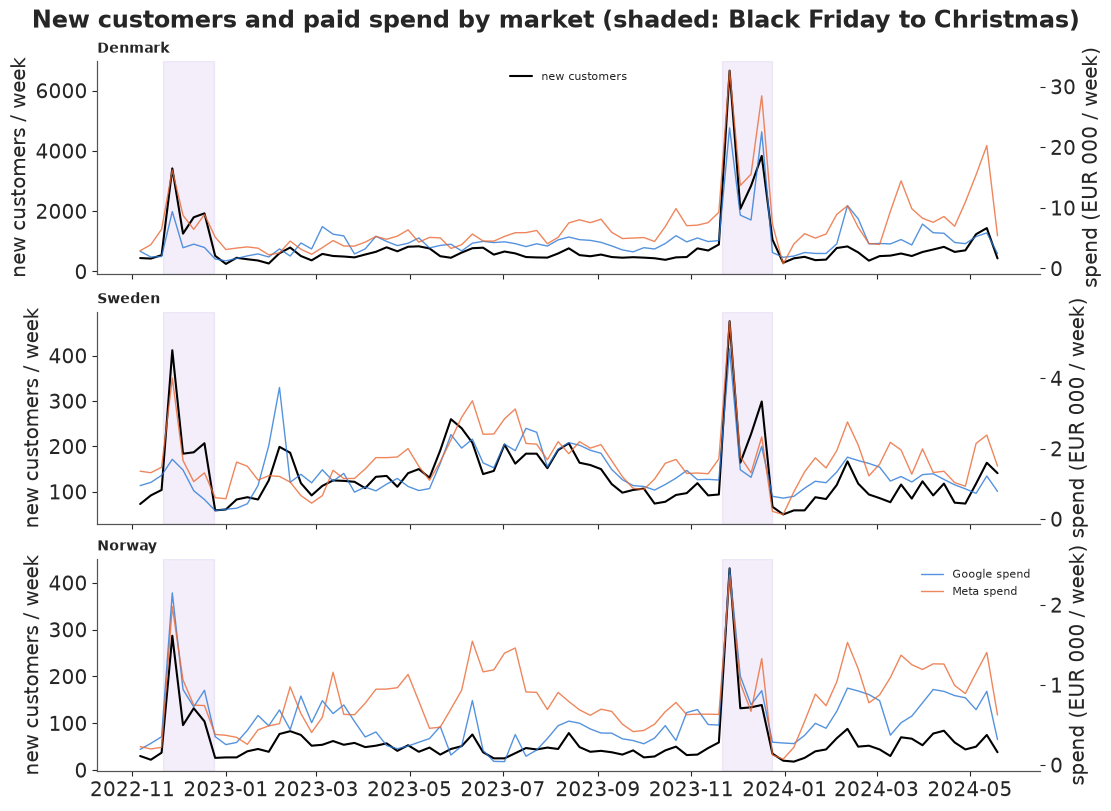

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for i, (ax, m) in enumerate(zip(axes, MARKETS)):
    ax.plot(weeks, Y[i], color="k", lw=1.5, label="new customers")
    ax.set_ylabel("new customers / week")
    ax2 = ax.twinx()
    for j, c in enumerate(CHANNELS):
        ax2.plot(weeks, S[i, j] / 1000, color=CH_COLOR[c], lw=1, alpha=0.8, label=f"{c} spend")
    ax2.set_ylabel("spend (EUR 000 / week)")
    ax2.grid(False)
    ax.set_title(m, loc="left", fontsize=10)
    for yr in (2022, 2023):
        ax.axvspan(pd.Timestamp(f"{yr}-11-21"), pd.Timestamp(f"{yr}-12-24"), color=PURPLE, alpha=0.1)
axes[0].legend(loc="upper center", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
fig.suptitle("New customers and paid spend by market (shaded: Black Friday to Christmas)");

What a modeller should see here:

- **Scale.** Denmark is the home market: about 14 times Norway's new customers and 8 times
  its spend. Norway averages about 60 new customers a week - a small market, where one
  market's data will not pin down two response curves.
- **Black Friday and the Christmas run-up** dominate everything: customers jump five- to
  eight-fold and spend jumps with them. If the model has no other explanation for those
  weeks, it will credit them to media. So the baseline gets explicit holiday controls.
- **Google and Meta move together** (correlation 0.84 in Denmark): the data alone can only
  weakly tell the two channels apart. That is the classic MMM identification problem, and
  one thing a hierarchy can help with.
- The blended cost per customer (all spend / all new customers) is 14-23 euros. That is an
  *upper bound on what media could possibly deliver*, not an estimate of it: some customers
  would have come anyway.

## 2 · The model

For market $m$, channel $c$, week $t$, with $x_{mct}$ = spend in units of that cell's
average week:

**Adstock** (carry-over over $L = 6$ weeks, normalised geometric weights):
$a_{mct} = \sum_{\ell=0}^{5} w_\ell\, x_{mc,t-\ell}$, $w_\ell \propto \theta_{mc}^\ell$.

**Saturation** (Hill curve with slope 1, Meridian's default for media, i.e. concave):
the channel adds $\beta_{mc}\, a/(a + k_{mc})$ new customers a week, where $k_{mc}$ is the
half-saturation point in units of average spend and $\beta_{mc}$ the ceiling.

**Priors in business units.** Rather than a prior on $\beta$ (whose scale depends on the
market's size), the model is parameterised by $\text{cpc}_{mc}$, the **cost per incremental
customer at the cell's average spend** (euros). At average spend ($a = 1$) the channel adds
$\beta/(1+k)$ customers a week for $\bar S_{mc}$ euros, so $\beta_{mc} = (\bar S_{mc}/
\text{cpc}_{mc})(1 + k_{mc})$. This is Meridian's ROI-prior idea: a marketer can say "a
customer bought by paid media probably costs between 15 and 170 euros", while nobody has a
feeling for $\beta$. And cost per customer in euros is a quantity that is plausibly
**exchangeable across markets** of one brand - the right scale on which to pool.

**Partial pooling** (non-centred):
$\log \text{cpc}_{mc} = \mu^{\text{cpc}}_c + \sigma^{\text{cpc}} z_{mc}$, and the same for
$\log k_{mc}$ and $\text{logit}\,\theta_{mc}$, with $z \sim N(0, 1)$. Each channel has its own
average across markets; how far a market may stray is learnt.

**Baseline** (the customers who would have come anyway), per market:
$\bar y_m \exp(b_m + \text{trend}_m t + \text{season}_m(t) + \text{holiday}_m(t))$, with two
yearly Fourier harmonics partially pooled across markets and three holiday indicators -
Black Friday week, the Christmas run-up weeks, and the holiday lull (weeks ending 24 Dec -
7 Jan) - also partially pooled. Media adds customers on top of the baseline, so "customers
bought by media" is well defined.

**Likelihood**: $y_{mt} \sim \text{NegativeBinomial}(\text{baseline}_{mt} + \sum_c
\text{media}_{mct},\ \alpha_m)$.

In [5]:
L_ADSTOCK = 6
HOLIDAYS = ["black_friday", "christmas_run_up", "holiday_lull"]
H = np.zeros((len(HOLIDAYS), T))
for bf in pd.to_datetime(["2022-11-25", "2023-11-24"]):
    i_bf = np.searchsorted(weeks, bf)  # the week (ending Sunday) that contains Black Friday
    H[0, i_bf] = 1
    for i in range(i_bf + 1, T):
        if weeks[i].month == 12 and weeks[i].day >= 24:
            break
        H[1, i] = 1
H[2] = [(w.month == 12 and w.day >= 24) or (w.month == 1 and w.day <= 7) for w in weeks]
for h, name in enumerate(HOLIDAYS):
    print(f"{name:17s}", [w.strftime("%d %b %y") for w in weeks[H[h] == 1]])

t_years = np.arange(T) * 7 / 365.25
doy = weeks.dayofyear.to_numpy() / 365.25
FOURIER = np.column_stack([f(2 * np.pi * k * doy) for k in (1, 2) for f in (np.sin, np.cos)])
S_MEAN = S.mean(axis=2)  # EUR per average week, (market, channel)
Y_MEAN = Y.mean(axis=1)
XS = S / S_MEAN[..., None]  # spend in units of the cell's average week
LAG = np.arange(T)[:, None] + (L_ADSTOCK - 1) - np.arange(L_ADSTOCK)[None, :]
# before the first week, assume spend continued at the first week's level
XLAG = np.concatenate([np.repeat(XS[..., :1], L_ADSTOCK - 1, axis=2), XS], axis=2)[..., LAG]


def adstock(theta):
    """theta (market, channel) -> adstocked spend (market, channel, week). XLAG is (m, c, t, lag)."""
    w = theta[..., None] ** pt.arange(L_ADSTOCK)
    w = w / w.sum(axis=-1, keepdims=True)
    return (XLAG * w[:, :, None, :]).sum(axis=-1)

black_friday      ['27 Nov 22', '26 Nov 23']
christmas_run_up  ['04 Dec 22', '11 Dec 22', '18 Dec 22', '03 Dec 23', '10 Dec 23', '17 Dec 23']
holiday_lull      ['25 Dec 22', '01 Jan 23', '24 Dec 23', '31 Dec 23', '07 Jan 24']


One function builds all the variants used below: `pooling` is `"partial"`, `"none"` (every
cell on its own, with the *same marginal prior* the hierarchy implies, so the comparison is
only about pooling) or `"full"` (one curve per channel for all markets). The prior arguments
are there for the sensitivity analysis of section 8.

In [6]:
SD_SCALE = {"cpc": 0.4, "k": 0.4, "theta": 0.5}  # half-normal scales of between-market sds


def build_mmm(pooling="partial", cpc_prior=(np.log(50.0), 0.7), k_prior=(np.log(1.5), 0.5),
              centred=False, sd_scale=SD_SCALE):
    coords = {"market": MARKETS, "channel": CHANNELS, "week": weeks, "holiday": HOLIDAYS,
              "fourier": ["sin1", "cos1", "sin2", "cos2"]}
    mc = ("market", "channel")
    with pm.Model(coords=coords) as model:
        # ---- media: channel-level means ...
        mu_cpc = pm.Normal("mu_log_cpc", cpc_prior[0], cpc_prior[1], dims="channel")
        mu_k = pm.Normal("mu_log_k", k_prior[0], k_prior[1], dims="channel")
        mu_th = pm.Normal("mu_logit_theta", -0.5, 0.8, dims="channel")
        # ... and market-level deviations
        if pooling == "partial":
            sd = {v: pm.HalfNormal(f"sd_{v}", sd_scale[v]) for v in sd_scale}
            if centred:
                log_cpc = pm.Normal("log_cpc", mu_cpc, sd["cpc"], dims=mc)
            else:
                log_cpc = mu_cpc + sd["cpc"] * pm.Normal("z_cpc", 0, 1, dims=mc)
            log_k = mu_k + sd["k"] * pm.Normal("z_k", 0, 1, dims=mc)
            logit_th = mu_th + sd["theta"] * pm.Normal("z_theta", 0, 1, dims=mc)
        elif pooling == "none":  # same marginal prior per cell, no sharing
            log_cpc = pm.Normal("log_cpc", cpc_prior[0], np.hypot(cpc_prior[1], SD_SCALE["cpc"]), dims=mc)
            log_k = pm.Normal("log_k", k_prior[0], np.hypot(k_prior[1], SD_SCALE["k"]), dims=mc)
            logit_th = pm.Normal("logit_theta", -0.5, np.hypot(0.8, SD_SCALE["theta"]), dims=mc)
        else:  # full pooling: one curve per channel
            log_cpc, log_k, logit_th = (pt.broadcast_to(v, (M, C)) for v in (mu_cpc, mu_k, mu_th))
        cpc = pm.Deterministic("cpc", pt.exp(log_cpc), dims=mc)
        k = pm.Deterministic("k", pt.exp(log_k), dims=mc)
        theta = pm.Deterministic("theta", pm.math.sigmoid(logit_th), dims=mc)
        beta = pm.Deterministic("beta", S_MEAN / cpc * (1 + k), dims=mc)  # customers/week ceiling
        a = adstock(theta)
        media = pm.Deterministic("media", beta[..., None] * a / (a + k[..., None]),
                                 dims=("market", "channel", "week"))
        # ---- baseline
        b0 = pm.Normal("b0", np.log(0.6), 0.5, dims="market")
        trend = pm.Normal("trend", 0.0, 0.5, dims="market")
        season = (pm.Normal("season_mu", 0.0, 0.3, dims="fourier")
                  + pm.HalfNormal("season_sd", 0.1) * pm.Normal("season_z", 0, 1, dims=("market", "fourier")))
        holiday = (pm.Normal("holiday_mu", 0.0, 1.0, dims="holiday")
                   + pm.HalfNormal("holiday_sd", 0.3) * pm.Normal("holiday_z", 0, 1, dims=("market", "holiday")))
        eta = b0[:, None] + trend[:, None] * t_years + pt.dot(season, FOURIER.T) + pt.dot(holiday, H)
        baseline = pm.Deterministic("baseline", Y_MEAN[:, None] * pt.exp(eta), dims=("market", "week"))
        alpha = pm.Gamma("alpha", 2.0, 0.1, dims="market")
        pm.NegativeBinomial("y", mu=baseline + media.sum(axis=1), alpha=alpha[:, None],
                            observed=Y, dims=("market", "week"))
    return model


def fit(model, label, **kw):
    """Sample, keeping only free variables and the small media parameters (not media/baseline)."""
    keep = [v.name for v in model.free_RVs] + ["cpc", "k", "theta", "beta"]
    kw = {"target_accept": 0.95, **kw}
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, var_names=keep, **kw)
    print(f"  {label}: divergences = {int(idata.sample_stats['diverging'].sum())}, "
          f"tuning steps = {idata.posterior.attrs.get('tuning_steps')}")
    return idata


def summary(idata, names, **kw):
    """az.summary one variable at a time: in ArviZ 1.3 a multi-variable call can mislabel
    rows when variables share a dimension (see the gotcha in the text)."""
    return pd.concat([az.summary(idata, var_names=[v], **kw) for v in names])

The prior on cost per incremental customer is centred on 50 euros with a log-sd of 0.7
(90% of the prior mass between about 16 and 160 euros for a channel's average; each market
can stray further). That is deliberately generous: it allows media to be almost as cheap as
the blended cost (every customer bought by ads) and allows it to be ten times dearer
(hardly any). The half-saturation point is centred on 1.5 times current average spend
(concave, but with room to grow), and adstock decay on about 0.4 per week.

## 3 · Prior predictive check, in euros

A prior predictive check should be read in the units the stakeholder uses. Four questions:
what cost per customer does the prior allow, what *marginal* cost of the next customer,
what share of new customers does it attribute to paid media, and are the implied weekly
customer numbers anywhere near reality?

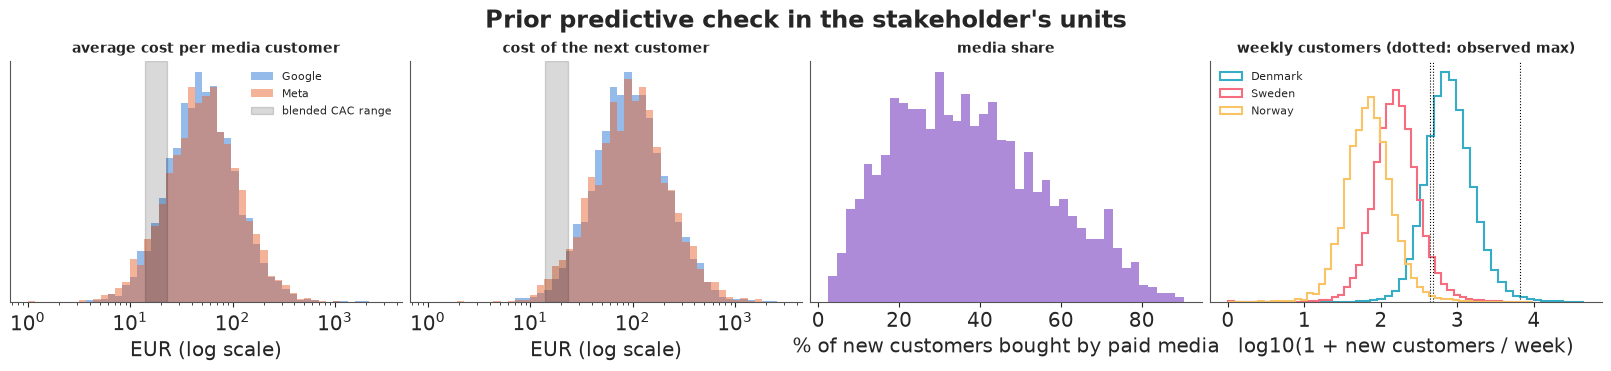

In [7]:
m_partial = build_mmm("partial")
prior = pm.sample_prior_predictive(model=m_partial, draws=1000, random_seed=RANDOM_SEED,
                                   var_names=["cpc", "k", "theta", "beta", "media", "baseline", "y"])


def draws_of(idata, names, group="posterior", n=1000, seed=RANDOM_SEED):
    """Dict of NumPy arrays with the sample dimension first."""
    ex = az.extract(idata, group=group, var_names=list(names), num_samples=n, random_seed=seed)
    return {v: ex[v].transpose("sample", ...).to_numpy() for v in names}


def adstock_np(theta):
    """theta (draws, market, channel) -> (draws, market, channel, week)."""
    w = theta[..., None] ** np.arange(L_ADSTOCK)
    w = w / w.sum(axis=-1, keepdims=True)
    return np.einsum("mctl,dmcl->dmct", XLAG, w)


def marginal_cost(p, r=None, last=52):
    """EUR per EXTRA customer for a small spend increase in each cell, over the last `last` weeks
    of spend scaled by r (market, channel). d/dr of beta*r*a/(r*a + k) is beta*a*k/(r*a + k)**2."""
    r = np.ones((M, C)) if r is None else r
    a = adstock_np(p["theta"])[..., -last:]
    ra = r[..., None] * a
    d_customers = (p["beta"][..., None] * a * p["k"][..., None] / (ra + p["k"][..., None]) ** 2).sum(-1)
    return S[..., -last:].sum(-1) / d_customers  # (draws, market, channel)


pp = draws_of(prior, ["cpc", "k", "theta", "beta", "media", "baseline"], group="prior")
pp_y = az.extract(prior, group="prior_predictive", var_names=["y"], num_samples=1000,
                  random_seed=RANDOM_SEED).transpose("sample", ...).to_numpy()  # one name: a DataArray
media_share = pp["media"].sum(axis=(2, 3)) / (pp["media"].sum(axis=(2, 3)) + pp["baseline"].sum(axis=2))
mcost_prior = marginal_cost(pp, last=T)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
bins = np.logspace(0, np.log10(3000), 50)
for j, c in enumerate(CHANNELS):
    axes[0].hist(pp["cpc"][:, :, j].ravel(), bins=bins, color=CH_COLOR[c], alpha=0.5, label=c)
    axes[1].hist(mcost_prior[:, :, j].ravel(), bins=bins, color=CH_COLOR[c], alpha=0.5, label=c)
for ax, title in zip(axes[:2], ["average cost per media customer", "cost of the next customer"]):
    ax.set(xscale="log", xlabel="EUR (log scale)", yticks=[])
    ax.set_title(title, fontsize=10)
    ax.axvspan(14, 23, color="k", alpha=0.15, label="blended CAC range")
axes[0].legend(fontsize=8)
axes[2].hist(100 * media_share.ravel(), bins=40, color=PURPLE, alpha=0.7)
axes[2].set(xlabel="% of new customers bought by paid media", yticks=[])
axes[2].set_title("media share", fontsize=10)
for i, m in enumerate(MARKETS):
    axes[3].hist(np.log10(pp_y[:, i].ravel() + 1), bins=50, histtype="step", lw=1.5, label=m)
    axes[3].axvline(np.log10(Y[i].max() + 1), color="k", lw=0.8, ls=":")
axes[3].set(xlabel="log10(1 + new customers / week)", yticks=[])
axes[3].set_title("weekly customers (dotted: observed max)", fontsize=10)
axes[3].legend(fontsize=8)
fig.suptitle("Prior predictive check in the stakeholder's units");

In [8]:
print("prior media share of new customers, 5/50/95%:", np.quantile(100 * media_share, [0.05, 0.5, 0.95]).round(0))
print("prior marginal cost per customer, 5/50/95%: ", np.quantile(mcost_prior, [0.05, 0.5, 0.95]).round(0))
for i, m in enumerate(MARKETS):
    print(f"{m:8s} weekly customers, prior 5/50/95%: {np.quantile(pp_y[:, i], [0.05, 0.5, 0.95]).round(0)}"
          f" | observed {Y[i].min()}-{Y[i].max()}")

prior media share of new customers, 5/50/95%: [10. 36. 72.]
prior marginal cost per customer, 5/50/95%:  [ 24.  94. 373.]
Denmark  weekly customers, prior 5/50/95%: [ 260.  769. 2652.] | observed 251-6662
Sweden   weekly customers, prior 5/50/95%: [ 54. 156. 489.] | observed 50-476
Norway   weekly customers, prior 5/50/95%: [ 23.  69. 219.] | observed 18-431


The prior knows the order of magnitude and little else, which is what it should know:

- **Average cost per media customer** sits mostly between 15 and 200 euros. Only a small
  fraction of draws fall below the blended CAC (grey band), which would mean paid media
  bought nearly all new customers on its own - possible for one channel, implausible for both.
- **The cost of the next customer** is higher (median about 90 euros) because the curves are
  concave: the prior already says "the next euro works less hard than the average euro".
- **Media share** is spread from about 10% to 70% of new customers: the prior takes no side in
  the "is marketing doing anything?" argument - the data will have to.
- **Weekly customers** land on the right scale in every market; the observed holiday peaks
  (dotted) are in the upper tail, as they should be for a prior that has not seen them.

## 4 · Fitting: centred vs non-centred

With three markets, the between-market sd of log cost per customer is estimated from three
numbers, and the data allow it to be very small. That is the setting for Neal's funnel:
in the **centred** form the six market-level costs are sampled directly around the channel
mean, and when the sd is small they are squeezed into a narrow neck the sampler cannot
enter. The **non-centred** form samples standardised deviations $z$ instead.

In [9]:
idata_centred = fit(build_mmm("partial", centred=True), "centred, target_accept 0.8", target_accept=0.8)
idata_nc80 = fit(m_partial, "non-centred, target_accept 0.8", target_accept=0.8)
idata = fit(m_partial, "non-centred, target_accept 0.95")
for lab, idt in [("centred", idata_centred), ("non-centred", idata_nc80), ("non-c., 0.95", idata)]:
    print(f"{lab:12s} sd_cpc: ESS bulk = {float(az.ess(idt.posterior['sd_cpc'])):.0f}, "
          f"r_hat = {float(az.rhat(idt.posterior['sd_cpc'])):.3f}; "
          f"max r_hat over cpc = {float(az.rhat(idt.posterior['cpc']).max()):.3f}")

  centred, target_accept 0.8: divergences = 59, tuning steps = 400


  non-centred, target_accept 0.8: divergences = 105, tuning steps = 400


  non-centred, target_accept 0.95: divergences = 1, tuning steps = 400
centred      sd_cpc: ESS bulk = 499, r_hat = 1.007; max r_hat over cpc = 1.003
non-centred  sd_cpc: ESS bulk = 210, r_hat = 1.015; max r_hat over cpc = 1.010
non-c., 0.95 sd_cpc: ESS bulk = 583, r_hat = 1.005; max r_hat over cpc = 1.005


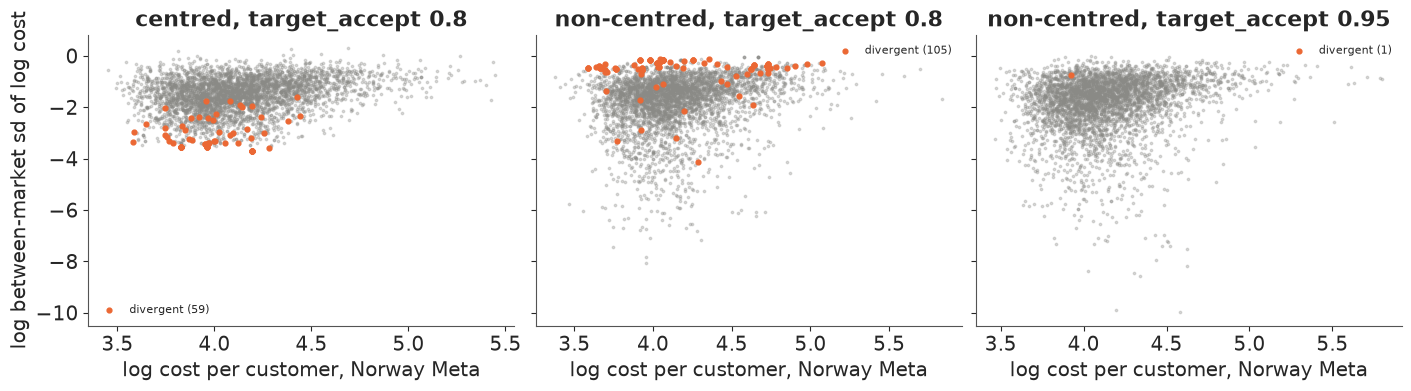

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (lab, idt) in zip(axes, [("centred, target_accept 0.8", idata_centred),
                                 ("non-centred, target_accept 0.8", idata_nc80),
                                 ("non-centred, target_accept 0.95", idata)]):
    sdv = idt.posterior["sd_cpc"].values.ravel()
    cv = np.log(idt.posterior["cpc"].sel(market="Norway", channel="Meta").values.ravel())
    dv = idt.sample_stats["diverging"].values.ravel().astype(bool)
    ax.scatter(cv[~dv], np.log(sdv[~dv]), s=3, alpha=0.3, color=GREY)
    ax.scatter(cv[dv], np.log(sdv[dv]), s=12, color=ORANGE, label=f"divergent ({dv.sum()})")
    ax.set(xlabel="log cost per customer, Norway Meta", title=lab)
    ax.legend(fontsize=8)
axes[0].set_ylabel("log between-market sd of log cost");

The three panels are one posterior explored three ways, and the two parameterisations fail
at **opposite ends** of it:

- **Centred** (left): the divergences sit in the neck of the funnel, at small between-market
  sd, and the draws stop well short of the region the non-centred sampler visits. The part
  of the posterior where the three markets are nearly identical is cut off: a bias toward
  *less* pooling that r_hat does not flag.
- **Non-centred** at the default step size (middle): the neck is explored freely, but the
  divergences move to the top - large between-market sd, where the markets decouple and,
  as in the unpooled fit of section 6, Denmark's two co-moving channels can trade credit
  along a narrow curved ridge. No reparameterisation removes that curvature.
- **Non-centred with `target_accept=0.95`** (right): a smaller step size gets round the ridge,
  leaving at most a handful of divergences.

(The exact counts change from run to run - nutpie is not bit-reproducible - but where the
divergences sit does not.) Non-centred plus a smaller step is the fit used from here on.

Diagnostics of the non-centred fit (default nutpie settings apart from `target_accept=0.95`):

In [11]:
del idata_centred, idata_nc80
summary(idata, ["mu_log_cpc", "mu_log_k", "mu_logit_theta", "sd_cpc", "sd_k", "sd_theta",
                "cpc", "k", "theta", "holiday_mu", "trend", "alpha"], round_to=2)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_log_cpc[Google],3.19,0.21,2.89,3.58,792.34,835.35,1.01,0.01,0.01
mu_log_cpc[Meta],4.02,0.29,3.61,4.51,1243.11,1609.08,1.00,0.01,0.01
mu_log_k[Google],1.32,0.43,0.62,2.00,4775.60,3159.22,1.00,0.01,0.01
mu_log_k[Meta],0.92,0.46,0.17,1.63,5297.18,3056.67,1.00,0.01,0.01
mu_logit_theta[Google],-1.36,0.49,-2.15,-0.61,4678.75,3066.93,1.00,0.01,0.01
mu_logit_theta[Meta],-1.58,0.61,-2.56,-0.63,5517.29,3486.12,1.00,0.01,0.01
sd_cpc,0.24,0.17,0.02,0.54,583.14,657.35,1.01,0.01,0.00
sd_k,0.46,0.32,0.04,1.04,1730.93,1499.90,1.00,0.01,0.00
sd_theta,0.37,0.28,0.03,0.89,2649.65,1964.13,1.00,0.00,0.00
"cpc[Denmark, Google]",23.58,6.72,15.98,34.82,1615.66,1630.34,1.00,0.18,0.32


In [12]:
rhat_max = max(float(az.rhat(idata.posterior[v]).max()) for v in idata.posterior.data_vars)
ess_min = min(float(az.ess(idata.posterior[v]).min()) for v in idata.posterior.data_vars)
print(f"all parameters: max r_hat = {rhat_max:.3f}, min bulk ESS = {ess_min:.0f}, "
      f"divergences = {int(idata.sample_stats['diverging'].sum())}")

all parameters: max r_hat = 1.005, min bulk ESS = 583, divergences = 1


All r_hat are at most 1.01 and the smallest bulk ESS (the between-market sd of cost) is
several hundred. What the parameters say:

- **Cost per incremental customer at average spend**: Google's channel average is about
  exp(3.2) = 24 euros, Meta's about exp(4.0) = 55 euros, with each market close to its
  channel average (the between-market sd of log cost is small, about 0.25).
- **Saturation** is weakly identified: half-saturation points of roughly 3-7 times average
  spend with 90% intervals from about 1 to 15. The observed spend range shows only gentle
  curvature, so where the curves flatten is partly the prior's call - section 8 tests it.
- **Carry-over** is short: a weekly decay near 0.2, so most of the effect lands in the week
  of spend.
- **Holidays**: the Black Friday week multiplies the baseline about 14-fold (exp(2.6)) and the
  Christmas run-up about 5-fold; the holiday lull is below normal. Without these controls,
  all of that would be available to be credited to the spend that rose with it.

## 5 · Posterior predictive check and the decomposition

Does the model reproduce the weekly series, including the holiday spikes and Norway's
noise? And how does it split each week into "would have come anyway" and "bought by Google /
Meta"?

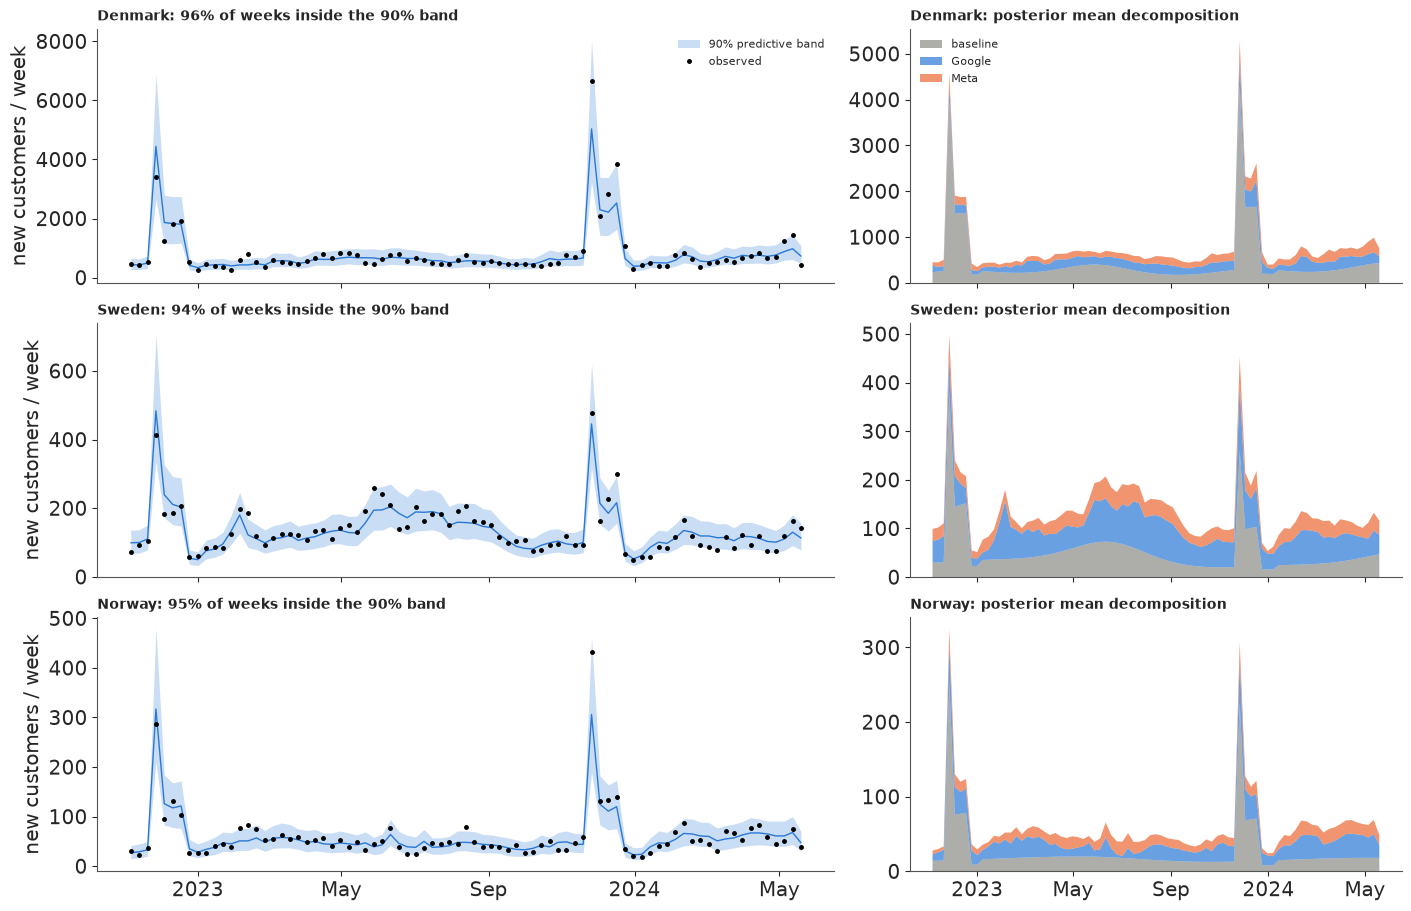

In [13]:
thin = idata.isel(draw=slice(None, None, 4))
ppc = pm.sample_posterior_predictive(thin, model=m_partial, var_names=["y", "media", "baseline"],
                                     random_seed=RANDOM_SEED, progressbar=False)
yrep = ppc.posterior_predictive["y"].stack(s=("chain", "draw")).transpose("s", ...).to_numpy()
media_post = ppc.posterior_predictive["media"].mean(("chain", "draw")).to_numpy()  # (m, c, t)
base_post = ppc.posterior_predictive["baseline"].mean(("chain", "draw")).to_numpy()
lo, hi = np.quantile(yrep, [0.05, 0.95], axis=0)
cover = ((Y >= lo) & (Y <= hi)).mean(axis=1)

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True, gridspec_kw={"width_ratios": [3, 2]})
for i, m in enumerate(MARKETS):
    ax = axes[i, 0]
    ax.fill_between(weeks, lo[i], hi[i], color=BLUE, alpha=0.25, lw=0, label="90% predictive band")
    ax.plot(weeks, np.median(yrep[:, i], axis=0), color=BLUE, lw=1)
    ax.plot(weeks, Y[i], "o", color="k", ms=2.5, label="observed")
    ax.set_title(f"{m}: {100 * cover[i]:.0f}% of weeks inside the 90% band", loc="left", fontsize=10)
    ax.set_ylabel("new customers / week")
    ax = axes[i, 1]
    ax.stackplot(weeks, base_post[i], media_post[i, 0], media_post[i, 1],
                 colors=[GREY, BLUE, ORANGE], alpha=0.7, labels=["baseline", "Google", "Meta"])
    ax.set_title(f"{m}: posterior mean decomposition", loc="left", fontsize=10)
for ax in axes[-1]:
    loc = mdates.MonthLocator(bymonth=[1, 5, 9])
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
axes[0, 0].legend(fontsize=8)
axes[0, 1].legend(fontsize=8, loc="upper left");

In [14]:
share = media_post.sum(axis=2) / (media_post.sum(axis=(1, 2)) + base_post.sum(axis=1))[:, None]
pd.DataFrame(100 * share, index=MARKETS, columns=[f"% of new customers from {c}" for c in CHANNELS]).round(0)

,% of new customers from Google,% of new customers from Meta
Denmark,24.0,19.0
Sweden,42.0,21.0
Norway,35.0,22.0


The 90% predictive bands contain 94-96% of the weeks in each market, including both Black
Friday peaks, so the model is, if anything, slightly cautious. The decomposition is the MMM's
actual claim: paid media bought roughly 45% of Denmark's new customers and about 55-65% of
Sweden's and Norway's, with Google carrying the larger share everywhere. Look at Sweden's
summer 2023 bump: new customers rose, Google spend rose with it, and the model gives most of
the bump to Google. That is either Google working, or Google's bidding following a demand
surge - the pattern E32 is about, and one this model cannot tell apart (section 8).

## 6 · What pooling buys - and what LOO does not see

Fit the same model with no pooling (each of the six cells on its own, with the same
marginal prior) and with full pooling (one curve per channel for all three markets).

In [15]:
m_none, m_full = build_mmm("none"), build_mmm("full")
idata_none = fit(m_none, "no pooling")
idata_full = fit(m_full, "full pooling")


def q(idt, v, qs=(0.05, 0.5, 0.95)):
    return idt.posterior[v].quantile(list(qs), dim=("chain", "draw")).to_numpy()  # (q, m, c)


cpc_tab = {}
for lab, idt in [("no pooling", idata_none), ("partial", idata), ("full pooling", idata_full)]:
    qq = q(idt, "cpc")
    cpc_tab[lab] = pd.DataFrame({f"{m} {c}": f"{qq[1, i, j]:.0f} [{qq[0, i, j]:.0f}, {qq[2, i, j]:.0f}]"
                                 for i, m in enumerate(MARKETS) for j, c in enumerate(CHANNELS)},
                                index=[lab]).T
print("average cost per incremental customer, EUR: median [90% interval]")
pd.concat(cpc_tab.values(), axis=1)

  no pooling: divergences = 0, tuning steps = 400


  full pooling: divergences = 0, tuning steps = 400
average cost per incremental customer, EUR: median [90% interval]


,no pooling,partial,full pooling
Denmark Google,"37 [18, 130]","22 [16, 35]","23 [19, 29]"
Denmark Meta,"26 [19, 48]","46 [26, 84]","58 [42, 97]"
Sweden Google,"22 [17, 31]","23 [18, 29]","23 [19, 29]"
Sweden Meta,"63 [38, 150]","57 [39, 100]","58 [42, 97]"
Norway Google,"27 [19, 50]","25 [20, 36]","23 [19, 29]"
Norway Meta,"78 [42, 196]","60 [42, 107]","58 [42, 97]"


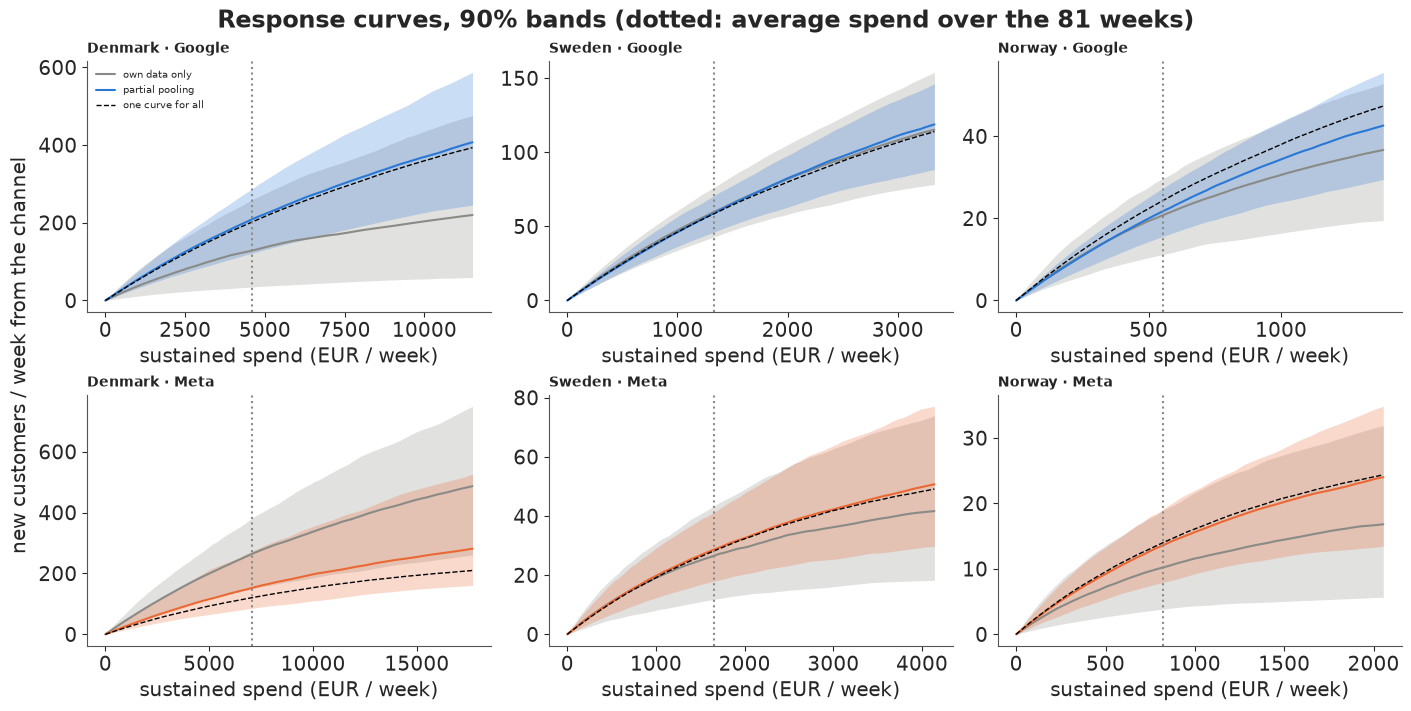

In [16]:
grid_mult = np.linspace(0, 2.5, 80)  # sustained weekly spend, multiples of the cell's average


def curves(idt, n=400):
    """Steady-state customers / week on the grid: (draws, market, channel, grid)."""
    p = draws_of(idt, ["beta", "k"], n=n)
    g = grid_mult[None, None, None, :]
    return p["beta"][..., None] * g / (g + p["k"][..., None])


cur_none, cur_part, cur_full = curves(idata_none), curves(idata), curves(idata_full)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, m in enumerate(MARKETS):
    for j, c in enumerate(CHANNELS):
        ax = axes[j, i]
        spend_axis = grid_mult * S_MEAN[i, j]
        for cv, col, lab in [(cur_none, GREY, "own data only"), (cur_part, CH_COLOR[c], "partial pooling"),
                             (cur_full, "k", "one curve for all")]:
            lo_, med_, hi_ = np.quantile(cv[:, i, j], [0.05, 0.5, 0.95], axis=0)
            if col == "k":
                ax.plot(spend_axis, med_, color="k", ls="--", lw=1, label=lab)
            else:
                ax.fill_between(spend_axis, lo_, hi_, color=col, alpha=0.25, lw=0)
                ax.plot(spend_axis, med_, color=col, lw=1.5, label=lab)
        ax.axvline(S_MEAN[i, j], color=GREY, ls=":")
        ax.set_title(f"{m} · {c}", fontsize=10, loc="left")
        ax.set_xlabel("sustained spend (EUR / week)")
    axes[0, i].legend(fontsize=7) if i == 0 else None
fig.supylabel("new customers / week from the channel")
fig.suptitle("Response curves, 90% bands (dotted: average spend over the 81 weeks)");

Two ways to go wrong without pooling, both visible in the table and the grey bands:

- **The small market is simply uncertain.** Norway's Meta curve on its own data allows
  anything from a nearly flat curve to a steep one: a cost per customer of about 40 to 200
  euros. One market's 81 weeks cannot pin down two curves when a week
  brings about 60 new customers.
- **The large market gets the split wrong.** Denmark has plenty of data, but Google and Meta
  move together there (correlation 0.84), so on its own it can only estimate their *sum*.
  The unpooled fit hands the credit the other way round from every other market (Meta cheaper
  than Google) with a Google interval running to over 100 euros. Pooling does not add data
  about Denmark; it adds the information that in the markets where the two channels *can*
  be told apart, Google is the cheaper one.

Partial pooling pulls both back toward the channel average and narrows the intervals.
Full pooling (dashed) goes further and forces one curve on all markets; partial pooling
ends up close to it here because the data favour a small between-market sd - but it let
the data decide that, and keeps Denmark's Meta somewhat cheaper than the others.

**Does LOO prefer the hierarchy?** All three models give a per-week likelihood, so PSIS-LOO
compares them directly.

In [17]:
loos = {}
for lab, idt, mdl in [("partial", idata, m_partial), ("no pooling", idata_none, m_none),
                      ("full pooling", idata_full, m_full)]:
    pm.compute_log_likelihood(idt, model=mdl, progressbar=False)
    loos[lab] = az.loo(idt, pointwise=True)
    loos[lab].log_weights = None
    del idt["log_likelihood"]
    bad = loos[lab].pareto_k.to_series()
    bad = bad[bad > 0.7]
    print(f"{lab:13s}: Pareto k > 0.7 for {len(bad)} of {M * T} weeks:",
          [f"{m} {pd.Timestamp(w):%d %b %y}" for m, w in bad.index])
az.compare(loos, round_to=1)

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


partial      : Pareto k > 0.7 for 2 of 243 weeks: ['Sweden 27 Nov 22', 'Norway 26 Nov 23']


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


no pooling   : Pareto k > 0.7 for 2 of 243 weeks: ['Denmark 26 Nov 23', 'Norway 26 Nov 23']


full pooling : Pareto k > 0.7 for 3 of 243 weeks: ['Denmark 26 Nov 23', 'Norway 27 Nov 22', 'Norway 26 Nov 23']


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
partial,0,0.0,0.0,NaN,,2 k̂ > 0.70,29.3,-1226.7,22.3,1.0
full pooling,1,-1.5,1.2,0.9,|elpd_diff| < 4,3 k̂ > 0.70,27.6,-1228.2,22.5,0.0
no pooling,2,-3.3,2.6,0.9,|elpd_diff| < 4,2 k̂ > 0.70,30.7,-1230.0,22.2,0.0


LOO ranks partial pooling first, but the differences are within about one standard error:
by predictive fit alone, the three models are indistinguishable. That is not a failure of
LOO but a fact about MMMs worth knowing. Week-to-week new customers are driven mostly by
the baseline and the holidays, and the *total* media contribution is similar across the
three models; what differs is how that total is split between channels and markets - and
two co-moving channels can split a total many ways with almost the same fit (the unpooled
Denmark estimate is exactly that). LOO scores predictions of new customers, not the
correctness of an attribution. The case for the hierarchy is structural (markets of one brand
are exchangeable) and practical (stabler curves, and a decision that does not rest on one
market's collinearity). The two or three weeks with high Pareto k, listed above, are Black
Friday weeks: each is most of the evidence for its own market's Black Friday effect, so
leaving it out changes the fit - expected, and too few to distort the comparison.

## 7 · The decision: reallocating a fixed budget

**The plan space.** Next year's budget equals the last 52 weeks' spend in every cell. A
plan multiplies each of the six cells' spend by a factor $r_{mc}$, keeping the week-to-week
pattern (Black Friday pushes and all), with the total fixed. Each factor is kept between
0.5 and 1.5: the curves are only informed near the spend levels actually observed, and a
plan that moves further than that is extrapolation, not estimation (PyMC-Marketing's
optimiser has the same budget bounds for the same reason).

**The objective.** Because adstock is linear, scaling a cell's spend by $r$ scales its
adstocked spend by $r$, so the customers a plan buys over the year are, for every posterior
draw, $\sum_{m,c,t} \beta_{mc}\, r_{mc} a_{mct} / (r_{mc} a_{mct} + k_{mc})$. The optimiser
(SLSQP) maximises either the **posterior mean** of the extra customers, or a **cautious**
objective, mean minus 1.65 posterior sds (roughly the 5th percentile of the gain). The
chosen plan is then evaluated over all posterior draws.

In [18]:
LAST = 52
BUDGET = S[..., -LAST:].sum(axis=-1)  # EUR per cell over the last 52 weeks
post = draws_of(idata, ["beta", "k", "theta"])


class Planner:
    """Customers bought by media over the last 52 weeks' pattern, for any spend multipliers."""

    def __init__(self, p):
        self.beta, self.k = p["beta"][..., None], p["k"][..., None]
        self.a = adstock_np(p["theta"])[..., -LAST:]
        self.now = self.customers(np.ones((M, C)))

    def customers(self, r):
        ra = np.reshape(r, (M, C))[..., None] * self.a
        return (self.beta * ra / (ra + self.k)).sum(axis=(1, 2, 3))

    def gain(self, r):
        return self.customers(r) - self.now

    def optimise(self, risk=0.0):
        def objective(v):
            g = self.gain(v)
            return -(g.mean() - risk * g.std()) / 1000

        budget = {"type": "eq", "fun": lambda v: v @ BUDGET.ravel() / BUDGET.sum() - 1}
        res = minimize(objective, np.ones(M * C), method="SLSQP", bounds=[(0.5, 1.5)] * (M * C),
                       constraints=[budget], options={"ftol": 1e-12, "maxiter": 500})
        assert res.success, res.message
        return res.x.reshape(M, C)


planner = Planner(post)
plan_mean = planner.optimise(risk=0.0)
plan_safe = planner.optimise(risk=1.65)
mcost_now = marginal_cost(post)

table = pd.DataFrame(index=pd.MultiIndex.from_product([MARKETS, CHANNELS], names=["market", "channel"]))
table["spend now (EUR 000/yr)"] = (BUDGET.ravel() / 1000).round(0)
table["marginal cost now (EUR)"] = [f"{np.median(v):.0f} [{np.quantile(v, 0.05):.0f}, {np.quantile(v, 0.95):.0f}]"
                                    for v in mcost_now.reshape(len(mcost_now), -1).T]
table["best-guess plan (EUR 000)"] = (plan_mean.ravel() * BUDGET.ravel() / 1000).round(0)
table["cautious plan (EUR 000)"] = (plan_safe.ravel() * BUDGET.ravel() / 1000).round(0)
table

spend now (EUR 000/yr) marginal cost now (EUR)  \
market  channel                                                   
Denmark Google                    269.0             30 [21, 53]   
        Meta                      430.0            69 [35, 147]   
Sweden  Google                     76.0             28 [22, 40]   
        Meta                       95.0            89 [55, 182]   
Norway  Google                     29.0             33 [25, 51]   
        Meta                       47.0            93 [61, 181]   

                 best-guess plan (EUR 000)  cautious plan (EUR 000)  
market  channel                                                      
Denmark Google                       403.0                    299.0  
        Meta                         313.0                    421.0  
Sweden  Google                       114.0                    114.0  
        Meta                          47.0                     47.0  
Norway  Google                        44.0                     39.0  
        Meta                          24.0                     24.0

In [19]:
def describe_plan(r, label):
    g = planner.gain(r)
    return pd.Series({"extra new customers / yr (median)": np.median(g),
                      "90% interval": f"[{np.quantile(g, 0.05):.0f}, {np.quantile(g, 0.95):.0f}]",
                      "P(beats current plan)": (g > 0).mean(),
                      "% more media customers": 100 * np.median(g / planner.now),
                      "EUR moved (000)": np.abs(r - 1).ravel() @ BUDGET.ravel() / 2000}, name=label)


print(f"media-bought new customers under the current plan: {np.median(planner.now):.0f} / yr "
      f"(90%: {np.quantile(planner.now, 0.05):.0f}-{np.quantile(planner.now, 0.95):.0f})")
plans = pd.concat([describe_plan(plan_mean, "best-guess plan"), describe_plan(plan_safe, "cautious plan")],
                  axis=1).T
plans.style.format({"extra new customers / yr (median)": "{:,.0f}", "P(beats current plan)": "{:.2f}",
                    "% more media customers": "{:.1f}", "EUR moved (000)": "{:.0f}"})

media-bought new customers under the current plan: 27001 / yr (90%: 22061-32255)


,extra new customers / yr (median),90% interval,P(beats current plan),% more media customers,EUR moved (000)
best-guess plan,"2,944","[-392, 5778]",0.92,11.2,187
cautious plan,"1,461","[475, 2413]",0.99,5.4,79


**Marginal cost**: at today's spend the next new customer costs about 30 euros through Google
in every market and 70-95 euros through Meta. These are higher than the *average* costs of
section 6 because the curves are concave, and they are the numbers a reallocation should
use - the average cost says nothing about the next euro.

**The best-guess plan** follows the gap: every Google line goes up by the maximum 50%, the
Meta lines in Sweden and Norway go down by 50%, and Danish Meta pays for the rest, moving
about 190,000 euros (a fifth of the budget). The median gain is roughly 2,900 extra new
customers a year, about 11% more than the ~27,000 that media buys now, with a 90% interval
from a small loss to nearly 6,000 and about a 92% chance of beating the current plan.

**The cautious plan** leaves Denmark nearly alone - the market where the Google/Meta split
is least certain - and makes almost the same moves in Sweden and Norway. It expects about
half the gain (roughly 1,500 customers, 90% interval about 500 to 2,400), but the chance of
doing worse than today falls to about 1%. That trade (expected value
for safety, concentrated on the part of the plan with the weakest evidence) is what a
risk-adjusted objective buys, and it is a choice for the business, not for the model.

Note that both plans hit the 0.5 / 1.5 bounds: **the guard rails, not the curves, set the size
of the move.** Widen them and the optimiser would happily go further, into spend levels
the model has never seen.

## 8 · How much of this is the prior, and how much is the data?

**Endogeneity first.** E32 showed that when spend chases demand - budgets raised for Black
Friday, bid algorithms that spend more when conversion rates are high - an MMM credits media
with customers who were coming anyway. Nothing in this model corrects for that, and it
matters *differentially*: Google here is mostly Performance Max and search, whose spend
follows search demand by design, while Meta spend is closer to planned. So Google's
low cost per customer is exactly the number most likely to be flattered by endogeneity,
and the reallocation above moves money toward it. The holiday controls remove the most
obvious shared shocks; they cannot remove day-to-day or week-to-week demand chasing.

**Prior sensitivity.** Without an experiment, the *level* of a response curve (how many
customers a euro buys) and its *curvature* are only partly pinned down by 81 weeks of
co-moving series. Refit with four alternative priors and ask what happens to the decision
numbers: the gain of the recommended (best-guess) plan, re-optimised gains, and the
Meta-vs-Google gap in marginal cost in Denmark, the largest budget line.

In [20]:
alternatives = {
    "main: cpc ~ 50 EUR, k ~ 1.5": {},
    "cheaper media: cpc ~ 25 EUR": {"cpc_prior": (np.log(25.0), 0.7)},
    "dearer media: cpc ~ 100 EUR": {"cpc_prior": (np.log(100.0), 0.7)},
    "early saturation: k ~ 0.5": {"k_prior": (np.log(0.5), 0.5)},
    "late saturation: k ~ 4": {"k_prior": (np.log(4.0), 0.5)},
    "looser pooling: sds ~ HalfNormal(1)": {"sd_scale": {"cpc": 1.0, "k": 1.0, "theta": 1.0}},
}
rows = []
for lab, kw in alternatives.items():
    idt = idata if not kw else fit(build_mmm("partial", **kw), lab)
    p = draws_of(idt, ["beta", "k", "theta"])
    pl = Planner(p)
    g_fixed = pl.gain(plan_mean)
    g_reopt = pl.gain(pl.optimise(risk=0.0))
    mcost = marginal_cost(p)
    rows.append({"prior": lab,
                 "media customers now / yr": np.median(pl.now),
                 "gain of recommended plan": np.median(g_fixed),
                 "P(recommended plan beats current)": (g_fixed > 0).mean(),
                 "gain if re-optimised": np.median(g_reopt),
                 "DK marginal cost Google": np.median(mcost[:, 0, 0]),
                 "DK marginal cost Meta": np.median(mcost[:, 0, 1])})
    if kw:
        del idt
sens = pd.DataFrame(rows).set_index("prior")
sens.round(2)

  cheaper media: cpc ~ 25 EUR: divergences = 0, tuning steps = 400


  dearer media: cpc ~ 100 EUR: divergences = 3, tuning steps = 400


  early saturation: k ~ 0.5: divergences = 9, tuning steps = 400


  late saturation: k ~ 4: divergences = 0, tuning steps = 400


  looser pooling: sds ~ HalfNormal(1): divergences = 4, tuning steps = 400


,media customers now / yr,gain of recommended plan,P(recommended plan beats current),gain if re-optimised,DK marginal cost Google,DK marginal cost Meta
prior,,,,,,
"main: cpc ~ 50 EUR, k ~ 1.5",27000.51,2944.18,0.92,2944.18,30.47,69.32
cheaper media: cpc ~ 25 EUR,27792.13,2667.37,0.91,2667.37,30.48,63.31
dearer media: cpc ~ 100 EUR,26520.21,2877.64,0.92,2877.64,31.04,71.44
early saturation: k ~ 0.5,26828.09,2472.46,0.88,2472.46,33.76,70.27
late saturation: k ~ 4,27383.28,2916.99,0.94,2916.99,28.80,57.06
looser pooling: sds ~ HalfNormal(1),28392.51,2658.12,0.84,2658.12,28.91,46.01


Priors that move the expected cost per customer by a factor of four or the saturation point
by a factor of eight barely change the decision: the recommended plan gains roughly
2,500-3,000 customers with a chance of about 90% of beating today's plan, and re-optimising
under each alternative lands on the same corner. Early saturation lowers the gain the most,
as it should: it makes the extra Google euros work less hard. Over the range of priors a
reasonable analyst might choose, the *level* of the curves is mostly data-driven here.

The prior that matters most is the one that looked most innocent: **how different markets may
be**. With three markets, the between-market sd is mostly prior (section 1 warned). Loosen it
and Denmark drifts back toward its own collinear estimate: the Danish Meta marginal cost falls
from about 70 to about 45 euros, the Google/Meta gap there narrows, and P(plan beats current)
drops to about 0.84. It is the Danish half of the plan that leans hardest on the hierarchy -
the half the cautious plan declined to make.

But this table only tests what the model is *uncertain* about. It cannot test what the model
*assumes*: that spend was set independently of demand. The endogeneity argument above
predicts exactly the pattern found - search-heavy Google looking cheap - so the honest
message to finance is: **robust to our priors, not robust to our assumptions**. The model says
where to test first, not how much to move without testing.

## 9 · Showing it to the people who decide

Everything above is for the analyst. A marketing lead or a finance partner needs four
things: what the response curves look like, what the plan will probably deliver, where the
next euro works hardest, and why the small markets' numbers can be trusted at all. Each
display below shows a real posterior quantity from this notebook, in euros and customers,
with no Greek letters.

### 9.1 What does each extra euro buy? Forty equally likely response curves

A band suggests one true curve with fuzzy edges. Forty curves drawn from the posterior show
what the model actually believes: a family of possible curves, each one consistent with the
data. The marks show where each budget line sits now and where the recommended plan puts it.

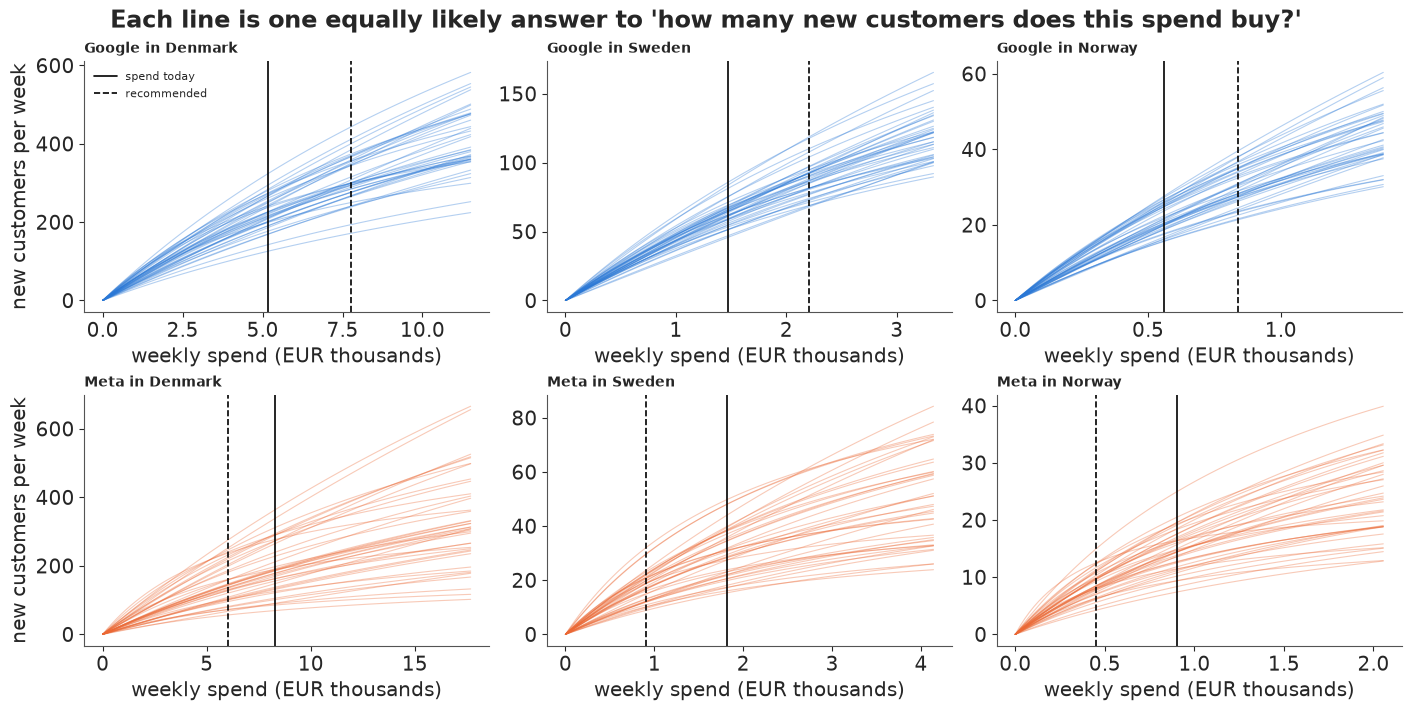

In [21]:
n_spag = 40
spag = cur_part[rng.choice(len(cur_part), n_spag, replace=False)]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
spend_now_wk = BUDGET / LAST
for i, m in enumerate(MARKETS):
    for j, c in enumerate(CHANNELS):
        ax = axes[j, i]
        spend_axis = grid_mult * S_MEAN[i, j]
        for s_ in spag:
            ax.plot(spend_axis / 1000, s_[i, j], color=CH_COLOR[c], lw=0.8, alpha=0.35)
        ax.axvline(spend_now_wk[i, j] / 1000, color="k", lw=1.2, label="spend today")
        ax.axvline(plan_mean[i, j] * spend_now_wk[i, j] / 1000, color="k", lw=1.2, ls="--",
                   label="recommended")
        ax.set_title(f"{c} in {m}", loc="left", fontsize=10)
        ax.set_xlabel("weekly spend (EUR thousands)")
    axes[0, 0].legend(fontsize=8, loc="upper left")
axes[0, 0].set_ylabel("new customers per week")
axes[1, 0].set_ylabel("new customers per week")
fig.suptitle("Each line is one equally likely answer to 'how many new customers does this spend buy?'");

### 9.2 Twenty equally likely outcomes of the plan

A quantile dotplot (Kay et al. 2016): twenty dots, each one a 5% chance, placed at the
posterior quantiles. "How likely is it that the plan loses customers?" becomes "count the
dots left of zero". Left: the full recommended plan. Right: a single, concrete move of
10,000 euros a year from the budget line with the most expensive marginal customer to the
one with the cheapest.

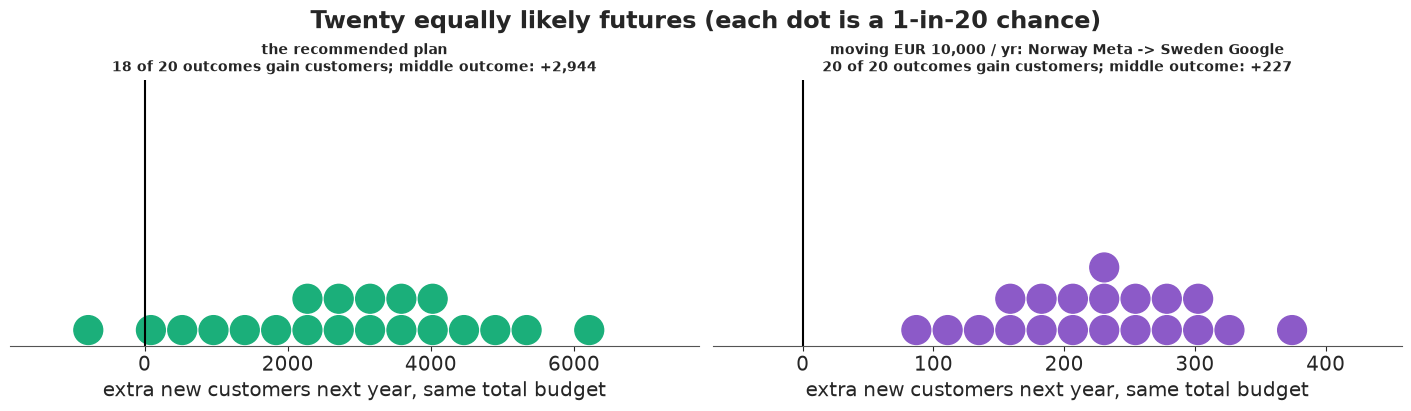

In [22]:
def quantile_dotplot(ax, samples, n_dots=20, n_bins=22, color=BLUE, xlim=None, max_stack=8):
    """Wilkinson-style dotplot of the n_dots quantiles of `samples` (as in E16)."""
    qd = np.quantile(samples, (np.arange(n_dots) + 0.5) / n_dots)
    lo_, hi_ = xlim if xlim is not None else (qd.min(), qd.max())
    edges = np.linspace(lo_, hi_, n_bins + 1)
    width = edges[1] - edges[0]
    cols = np.clip(np.digitize(qd, edges) - 1, 0, n_bins - 1)
    heights = np.zeros(n_bins, int)
    for cix in cols:
        ax.add_patch(Ellipse((edges[cix] + width / 2, heights[cix] + 0.5), width * 0.92, 0.92, color=color))
        heights[cix] += 1
    ax.set(xlim=(lo_, hi_), ylim=(0, max_stack + 0.5), yticks=[])
    ax.set_aspect(width)
    sns.despine(ax=ax, left=True)
    return qd


med_mc = np.median(mcost_now, axis=0)
src, dst = np.unravel_index(med_mc.argmax(), med_mc.shape), np.unravel_index(med_mc.argmin(), med_mc.shape)
MOVE = 10_000.0
r_move = np.ones((M, C))
r_move[src] -= MOVE / BUDGET[src]
r_move[dst] += MOVE / BUDGET[dst]
g_plan, g_move = planner.gain(plan_mean), planner.gain(r_move)
move_label = f"{MARKETS[src[0]]} {CHANNELS[src[1]]} -> {MARKETS[dst[0]]} {CHANNELS[dst[1]]}"

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, g, col, title in [(axes[0], g_plan, AQUA, "the recommended plan"),
                          (axes[1], g_move, PURPLE, f"moving EUR 10,000 / yr: {move_label}")]:
    span = max(abs(np.quantile(g, 0.01)), abs(np.quantile(g, 0.99))) * 1.1
    qd = quantile_dotplot(ax, g, color=col, xlim=(min(-0.15 * span, np.quantile(g, 0.01) * 1.1), span))
    ax.axvline(0, color="k", lw=1.5)
    n_neg = int((qd < 0).sum())
    ax.set_xlabel("extra new customers next year, same total budget")
    ax.set_title(f"{title}\n{20 - n_neg} of 20 outcomes gain customers; "
                 f"middle outcome: {np.median(g):+,.0f}", fontsize=10)
fig.suptitle("Twenty equally likely futures (each dot is a 1-in-20 chance)", y=1.04);

### 9.3 Where does the next 1,000 euros work hardest?

For each budget line, the chance that the next 1,000 euros there buys more new customers
than the same 1,000 euros spread across the current plan (the budget-weighted average
of all six lines). Green: a good place to add money; purple: a good place to take it from.
The number underneath is the model's middle estimate of what the next new customer costs
there.

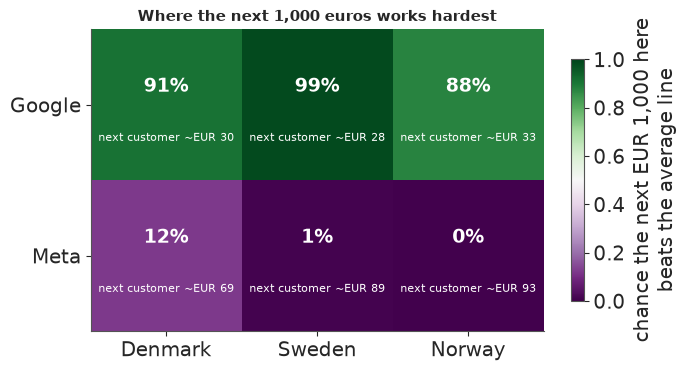

In [23]:
next_1000 = 1000.0 / mcost_now  # customers per extra 1,000 EUR, (draws, m, c)
avg_1000 = (next_1000 * BUDGET).sum(axis=(1, 2)) / BUDGET.sum()
p_better = (next_1000 > avg_1000[:, None, None]).mean(axis=0)

fig, ax = plt.subplots(figsize=(7, 3.6))
im = ax.imshow(p_better.T, cmap="PRGn", vmin=0, vmax=1)
for i in range(M):
    for j in range(C):
        ax.text(i, j - 0.12, f"{100 * p_better[i, j]:.0f}%", ha="center", va="center", fontsize=14,
                color="white" if abs(p_better[i, j] - 0.5) > 0.35 else "k", weight="bold")
        ax.text(i, j + 0.22, f"next customer ~EUR {med_mc[i, j]:.0f}", ha="center", va="center", fontsize=8,
                color="white" if abs(p_better[i, j] - 0.5) > 0.35 else "k")
ax.set(xticks=range(M), xticklabels=MARKETS, yticks=range(C), yticklabels=CHANNELS)
ax.grid(False)
plt.colorbar(im, ax=ax, label="chance the next EUR 1,000 here\nbeats the average line", shrink=0.8)
ax.set_title("Where the next 1,000 euros works hardest", fontsize=11);

### 9.4 Small markets borrow strength

Why trust a number for Norway, where only about 60 new customers arrive a week? Because
the model does not estimate Norway alone. Each line below is a 90% range for what a
customer costs in euros: grey from the market's own data only, coloured from the model that
also learns from the other two markets. The dashed line is the channel's average across
markets.

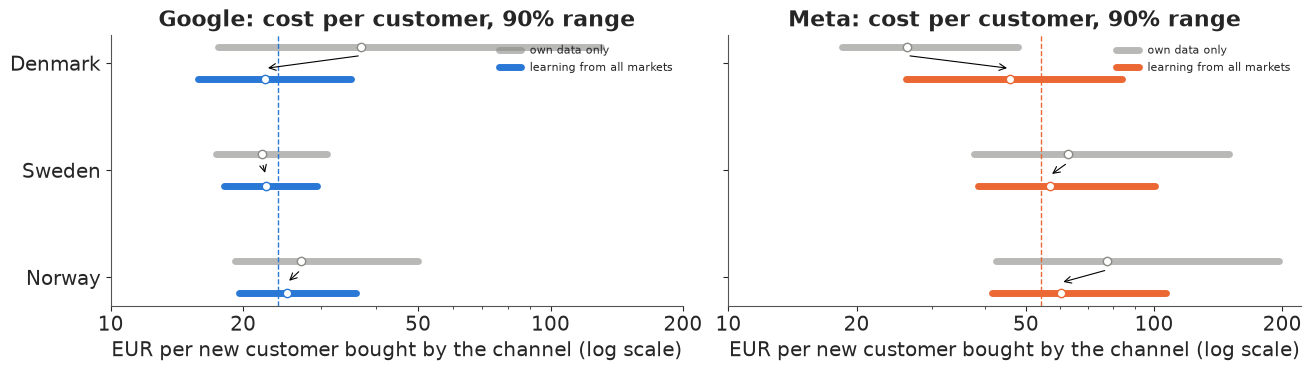

In [24]:
qn, qp = q(idata_none, "cpc"), q(idata, "cpc")
mu_ch = np.exp(idata.posterior["mu_log_cpc"].median(("chain", "draw")).to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for j, (ax, c) in enumerate(zip(axes, CHANNELS)):
    for i, m in enumerate(MARKETS):
        y0 = M - 1 - i
        ax.plot([qn[0, i, j], qn[2, i, j]], [y0 + 0.15] * 2, color=GREY, lw=5, solid_capstyle="round",
                alpha=0.6, label="own data only" if i == 0 else None)
        ax.plot(qn[1, i, j], y0 + 0.15, "o", color="white", mec=GREY, ms=6)
        ax.plot([qp[0, i, j], qp[2, i, j]], [y0 - 0.15] * 2, color=CH_COLOR[c], lw=5,
                solid_capstyle="round", label="learning from all markets" if i == 0 else None)
        ax.plot(qp[1, i, j], y0 - 0.15, "o", color="white", mec=CH_COLOR[c], ms=6)
        ax.annotate("", xy=(qp[1, i, j], y0 - 0.05), xytext=(qn[1, i, j], y0 + 0.07),
                    arrowprops={"arrowstyle": "->", "color": "k", "lw": 0.8})
    ax.axvline(mu_ch[j], color=CH_COLOR[c], ls="--", lw=1)
    ax.set(xscale="log", xlabel="EUR per new customer bought by the channel (log scale)",
           title=f"{c}: cost per customer, 90% range")
    ax.set_xticks([10, 20, 50, 100, 200], labels=["10", "20", "50", "100", "200"])
    ax.legend(fontsize=8, loc="upper right")
axes[0].set(yticks=range(M), yticklabels=MARKETS[::-1]);

What each display is for, and what it says here:

- **Forty response curves** make "we are not sure" concrete without an interval in sight. In
  Denmark the curves fan out widely - the two channels there are hard to separate - while
  the Swedish and Norwegian Google curves are tight. The dashed marks show that the plan
  moves spend *along* the curves the data know, never past their ends.
- **Twenty dots** answer the question finance will actually ask - "could this lose us
  customers?" - by counting: 18 of 20 outcomes of the full plan gain, two do not; the small
  concrete move from Norwegian Meta to Swedish Google gains in all twenty.
- **The heatmap** replaces six intervals with one probability per budget line and the one
  number a marketer uses (what the next customer costs). Read it as "take from purple, add to
  green".
- **Borrowing strength** is the hierarchy explained without the word: each market's own
  range (grey) is pulled toward what the other markets say (coloured), most where its own
  data are weakest - Norway's Meta and Denmark's split.

All four should travel with the caveat of section 8: these are the model's odds, given that
spend did not chase demand. Moving from "the model's odds" to "the world's odds" is what a
geo experiment is for.

### 9.5 Export for the web page

The decision-relevant results go into one small JSON file (a few hundred draws, curves as
quantiles on a grid, plain-English headlines), from which a page for non-technical readers
can be built without re-running the model.

In [25]:
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
cell = [f"{m}|{c}" for m in MARKETS for c in CHANNELS]
sub = rng.choice(len(g_plan), 300, replace=False)
qs = [0.05, 0.25, 0.5, 0.75, 0.95]
curve_q = np.quantile(cur_part, qs, axis=0)  # (q, m, c, grid)
export = {
    "id": "E33",
    "title": "Hierarchical multi-market MMM: where should next year's paid budget go?",
    "brand": "Scandinavian apparel brand (anonymised, Conjura open MMM data, CC BY 4.0)",
    "period": f"{weeks[0].date()} to {weeks[-1].date()} (81 weeks)",
    "currency": "EUR (fixed ECB 2023 average rates)",
    "markets": MARKETS, "channels": CHANNELS, "cells": cell,
    "current_plan_eur_per_year": dict(zip(cell, BUDGET.ravel().round(0).tolist())),
    "recommended_plan_eur_per_year": dict(zip(cell, (plan_mean * BUDGET).ravel().round(0).tolist())),
    "cautious_plan_eur_per_year": dict(zip(cell, (plan_safe * BUDGET).ravel().round(0).tolist())),
    "media_customers_now_per_year": {"median": float(np.median(planner.now)),
                                     "q05": float(np.quantile(planner.now, 0.05)),
                                     "q95": float(np.quantile(planner.now, 0.95))},
    "plan_gain": {"unit": "extra new customers next year",
                  "draws": g_plan[sub].round(0).astype(int).tolist(),
                  "median": float(np.median(g_plan)), "q05": float(np.quantile(g_plan, 0.05)),
                  "q95": float(np.quantile(g_plan, 0.95)), "p_beats_current": float((g_plan > 0).mean())},
    "move_example": {"from": f"{MARKETS[src[0]]}|{CHANNELS[src[1]]}", "to": f"{MARKETS[dst[0]]}|{CHANNELS[dst[1]]}",
                     "eur_per_year": MOVE, "draws": g_move[sub].round(0).astype(int).tolist(),
                     "median": float(np.median(g_move)), "p_positive": float((g_move > 0).mean())},
    "marginal_cost_eur": {"unit": "EUR per extra new customer at today's spend",
                          **{f"q{int(100 * qq):02d}": dict(zip(cell, np.quantile(mcost_now, qq, axis=0).ravel().round(1).tolist()))
                             for qq in qs},
                          "draws": {cl: v.round(1).tolist() for cl, v in
                                    zip(cell, mcost_now[sub[:200]].reshape(200, -1).T)}},
    "p_next_1000_beats_average": dict(zip(cell, p_better.ravel().round(3).tolist())),
    "response_curves": {"unit": "new customers per week at a sustained weekly spend",
                        "spend_eur_per_week": {cl: (grid_mult * S_MEAN.ravel()[n]).round(0).tolist()
                                               for n, cl in enumerate(cell)},
                        "spend_today_eur_per_week": dict(zip(cell, spend_now_wk.ravel().round(0).tolist())),
                        "quantiles": {f"q{int(100 * qq):02d}": {cl: curve_q[n_q].reshape(M * C, -1)[n].round(1).tolist()
                                                                 for n, cl in enumerate(cell)}
                                      for n_q, qq in enumerate(qs)}},
    "shrinkage_cost_per_customer_eur": {
        "own_data_only": {cl: qn[:, n // C, n % C].round(1).tolist() for n, cl in enumerate(cell)},
        "pooled": {cl: qp[:, n // C, n % C].round(1).tolist() for n, cl in enumerate(cell)},
        "channel_average": dict(zip(CHANNELS, mu_ch.round(1).tolist())), "quantiles": [0.05, 0.5, 0.95]},
    "prior_sensitivity": sens.reset_index().round(3).to_dict(orient="records"),
    "headlines": {},  # filled below
}
lo_c, hi_c = np.unravel_index(med_mc.argmin(), med_mc.shape), np.unravel_index(med_mc.argmax(), med_mc.shape)
i_no, j_me = MARKETS.index("Norway"), CHANNELS.index("Meta")
export["headlines"] = HEADLINES = {
    "plan_gain": (f"Re-splitting the same total budget across channels and markets most likely brings "
                  f"about {np.median(g_plan):,.0f} extra new customers next year (9 in 10 chance: "
                  f"{np.quantile(g_plan, 0.05):,.0f} to {np.quantile(g_plan, 0.95):,.0f}); the chance it "
                  f"beats today's plan is {(g_plan > 0).mean():.0%}."),
    "move_example": (f"Moving EUR 10,000 a year from {move_label.replace(' -> ', ' to ')} most likely "
                     f"adds about {np.median(g_move):,.0f} new customers; the chance it helps at all is "
                     + ("over 99%." if (g_move > 0).mean() > 0.99 else f"{(g_move > 0).mean():.0%}.")),
    "marginal_cost": (f"The next new customer is cheapest via {CHANNELS[lo_c[1]]} in {MARKETS[lo_c[0]]} "
                      f"(about EUR {med_mc[lo_c]:.0f}) and dearest via {CHANNELS[hi_c[1]]} in "
                      f"{MARKETS[hi_c[0]]} (about EUR {med_mc[hi_c]:.0f})."),
    "shrinkage": (f"On its own data, Norway's cost per Meta customer could be anywhere from EUR "
                  f"{qn[0, i_no, j_me]:.0f} to {qn[2, i_no, j_me]:.0f}; learning from Denmark and Sweden "
                  f"narrows that to EUR {qp[0, i_no, j_me]:.0f}-{qp[2, i_no, j_me]:.0f}."),
    "caveat": ("These are model estimates without any experiment. Google spend partly follows demand, "
               "which flatters Google in every model of this kind: test before moving large sums."),
}
out = root / ".scratch" / "artifact" / "E33.json"
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, separators=(",", ":")))
print(f"wrote {out.relative_to(root)} ({out.stat().st_size / 1024:.0f} KB)")
for v in HEADLINES.values():
    print("-", v)

wrote .scratch/artifact/E33.json (30 KB)
- Re-splitting the same total budget across channels and markets most likely brings about 2,944 extra new customers next year (9 in 10 chance: -392 to 5,778); the chance it beats today's plan is 92%.
- Moving EUR 10,000 a year from Norway Meta to Sweden Google most likely adds about 227 new customers; the chance it helps at all is over 99%.
- The next new customer is cheapest via Google in Sweden (about EUR 28) and dearest via Meta in Norway (about EUR 93).
- On its own data, Norway's cost per Meta customer could be anywhere from EUR 42 to 196; learning from Denmark and Sweden narrows that to EUR 42-107.
- These are model estimates without any experiment. Google spend partly follows demand, which flatters Google in every model of this kind: test before moving large sums.


The page export above keeps a few hundred draws. The interactive Lumen reports in `reports/`
use the **full posterior** instead: every chain and draw of the fitted parameters, plus the
quantities derived from them over all the draws they were computed on
(`reports/posteriors/E33.nc`, see `reports/README.md`).

In [26]:
from pymc_challenges.export import save_posterior

save_posterior("E33", idata, {
    "plan_gain": (("sample",), g_plan, {}, "new customers per year",
                  "extra new customers next year from the recommended budget split versus the current one (same total spend)"),
    "move_10k_norway_meta_to_sweden_google": (("sample",), g_move, {}, "new customers per year",
                                               "extra new customers from moving EUR 10,000 a year from Norway Meta to Sweden Google"),
    "marginal_cost_eur": (("sample", "market", "channel"), mcost_now, {"market": MARKETS, "channel": CHANNELS},
                          "EUR per new customer", "cost of one extra new customer at today's spend"),
    "customers_per_week": (("sample", "market", "channel", "spend_multiple"), cur_part,
                           {"market": MARKETS, "channel": CHANNELS, "spend_multiple": grid_mult}, "new customers per week",
                           "steady-state new customers per week at a sustained weekly spend (x: multiple of the cell's average weekly spend)"),
}, x_dims=("spend_multiple",));

wrote reports/posteriors/E33.nc: 22 parameters x 4000 draws; 4 derived quantities; 3.1 MB


## What to take away

- **An MMM is adstock + saturation + a baseline + a prior**, and each piece is a few lines of
  PyMC. Building it yourself makes every assumption visible - including the ones that
  decide the answer.
- **Parameterise in business units.** Priors on cost per incremental customer can be checked
  against numbers a marketer knows (blended CAC), are exchangeable across markets, and put
  the prior on the quantity the data inform best: the level of the curve at current spend.
- **Pool curves across markets.** Small markets get usable curves; collinear markets get a
  sensible split. Centred and non-centred forms fail at opposite ends of the posterior;
  look at *where* the divergences are before choosing a fix.
- **LOO will not tell you the attribution is right.** Models with very different channel
  splits predict new customers almost equally well.
- **Optimise on the posterior, then evaluate over it.** Report the expected gain, its range,
  and P(new plan beats current); know that bounds, not curves, often set the size of the move;
  a risk-adjusted objective moves money where the evidence is strongest.
- **Separate what the priors can change from what the assumptions can.** A prior sensitivity
  that comes back clean is not a validation: endogenous spend biases every channel curve, and
  only an experiment (next section, item 1) can tell you by how much.

## Try it yourself

1. **Add a lift test.** Suppose the brand ran a two-week geo holdout that switched Meta off in
   Norway and measured $\Delta$ fewer new customers with standard error $s$ (this dataset has
   no such experiment, so do not invent one for a real report). The model's prediction of
   that experiment is a deterministic function of the parameters: the media customers of
   Norway-Meta summed over the test weeks (and the adstock tail after them), computed with
   spend set to zero minus spend as observed. Add
   `pm.Normal("lift", mu=predicted_lift, sigma=s, observed=delta)`. This is how PyMC-Marketing
   and Meridian calibrate to experiments, and it pins down the *level* of the curve that
   section 8 showed is partly prior-driven. How much does one such test narrow the Norway
   Meta curve - and, through the hierarchy, the Denmark and Sweden Meta curves?
2. **Split Google.** Performance Max and paid search capture existing demand; video and
   shopping less so. Split Google into two channels, give each its own pooled curve, and see
   whether the recommended shift toward Google survives. Then add E32's copula control for
   the demand-chasing channel.
3. **Pool on a different scale.** Replace the cost-per-customer parameterisation with
   Meridian's alternative (a coefficient on spend scaled by market population or by the
   market's median spend) and pool that instead. Which markets move, and does the decision
   change? Pool the Hill slope too (free slope, `LogNormal(0, 0.3)`): do S-shaped curves
   appear, and are they supported by LOO?